## **Target outcome of this notebook**

AirBnB acts as a broker between listing owners and customers. It sets up prices of listing according to multiple parameters and provides independence to listing owners to decide their own prices. However, with growing business , it would be a better idea if AirBnB can help new owners registering into portal with estimating prices that could enable them more customers and also provide affordable accomodation options to customers. We will build up a model which on basis of past pattern sets up smart pricing mechanism.

## Import Libraries

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

In [ ]:
# importing important libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
plt.style.use('ggplot')

%matplotlib inline

# **Data Exploration**

Observe the data and find attributes.

Find null values and correct it.



In [ ]:
# reading the data
data_abb=pd.read_csv('/content/AB_NYC_2019.csv')
data_abb.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
data_abb.reset_index()

,index,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [ ]:
data_abb.drop('id',axis=1,inplace=True)

In [ ]:
data_abb.head()

,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
data_abb.columns

Index(['name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'latitude', 'longitude', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

In [ ]:
data_abb=data_abb[['name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'latitude', 'longitude', 'room_type', 'minimum_nights',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365','price']]

In [ ]:
data_abb.head()

,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price
0,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,1,9,2018-10-19,0.21,6,365,149
1,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,1,45,2019-05-21,0.38,2,355,225
2,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,3,0,NaN,NaN,1,365,150
3,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,1,270,2019-07-05,4.64,1,194,89
4,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,10,9,2018-11-19,0.10,1,0,80


In [ ]:
data_abb.shape

(48895, 15)

There are 48895 observations in this sample datasets provided by AirBnB with 15 variables. My target for this dataset is Price. This needs re-setting of columns in dataframe

In [ ]:
data_abb.host_id.nunique()

37457

There are 37457 hosts listed on Dataset with 48895 listing. This means multiple hosts has multiple listings.

### **What can be derived from this data?**

1. What type of model can be assigned to this dataset? Ans. Regression model for predicting the prices.

2. What kind of evaluation metrics will you use for this model? Ans. Since, it is a linear model regression problem, we will use explained variance score,mean-squared-error, and R^2 score for evaluation .

3. How will this predictive model help the client? Ans. The client can predict prices according to location and condition of facility and negotiate with host with a range of prices. This will help in building a better and affordable listing for customers and set right expectations for customers at affordable prices. If prices are set high by host, then it would be a loss outcome for all-host,airbnb and customer.





## **DATA CLEANING**

In [ ]:
#checking the data
data_abb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            48879 non-null  object 
 1   host_id                         48895 non-null  int64  
 2   host_name                       48874 non-null  object 
 3   neighbourhood_group             48895 non-null  object 
 4   neighbourhood                   48895 non-null  object 
 5   latitude                        48895 non-null  float64
 6   longitude                       48895 non-null  float64
 7   room_type                       48895 non-null  object 
 8   minimum_nights                  48895 non-null  int64  
 9   number_of_reviews               48895 non-null  int64  
 10  last_review                     38843 non-null  object 
 11  reviews_per_month               38843 non-null  float64
 12  calculated_host_listings_count  

In [ ]:
data_abb.isna().sum()

name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
price                                 0
dtype: int64

In [ ]:
data_abb.last_review

0        2018-10-19
1        2019-05-21
2               NaN
3        2019-07-05
4        2018-11-19
            ...    
48890           NaN
48891           NaN
48892           NaN
48893           NaN
48894           NaN
Name: last_review, Length: 48895, dtype: object

Last Review is last time any customer has

In [ ]:
# converting last_review to datetime
# replacing NaN values with 0
data_abb['last_review']=pd.to_datetime(data_abb['last_review'])
data_abb.last_review.fillna(max(data_abb.last_review),inplace=True)
data_abb.reviews_per_month.fillna(0,inplace=True)

In [ ]:
#removing unwanted columns
data_abb.drop(['name','host_name'],axis=1,inplace=True)

In [ ]:
#checking if any null values present now
data_abb.isna().sum().sum()

0

We have removed all the null values

In [ ]:
data_abb.describe()

,host_id,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price
count,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,6.762001e+07,40.728949,-73.952170,7.029962,23.274466,1.090910,7.143982,112.781327,152.720687
std,7.861097e+07,0.054530,0.046157,20.510550,44.550582,1.597283,32.952519,131.622289,240.154170
min,2.438000e+03,40.499790,-74.244420,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,7.822033e+06,40.690100,-73.983070,1.000000,1.000000,0.040000,1.000000,0.000000,69.000000
50%,3.079382e+07,40.723070,-73.955680,3.000000,5.000000,0.370000,1.000000,45.000000,106.000000
75%,1.074344e+08,40.763115,-73.936275,5.000000,24.000000,1.580000,2.000000,227.000000,175.000000
max,2.743213e+08,40.913060,-73.712990,1250.000000,629.000000,58.500000,327.000000,365.000000,10000.000000


In [ ]:
data_abb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   host_id                         48895 non-null  int64         
 1   neighbourhood_group             48895 non-null  object        
 2   neighbourhood                   48895 non-null  object        
 3   latitude                        48895 non-null  float64       
 4   longitude                       48895 non-null  float64       
 5   room_type                       48895 non-null  object        
 6   minimum_nights                  48895 non-null  int64         
 7   number_of_reviews               48895 non-null  int64         
 8   last_review                     48895 non-null  datetime64[ns]
 9   reviews_per_month               48895 non-null  float64       
 10  calculated_host_listings_count  48895 non-null  int64         
 11  av

In [ ]:
data_abb.head()

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price
0,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,1,9,2018-10-19,0.21,6,365,149
1,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,1,45,2019-05-21,0.38,2,355,225
2,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,3,0,2019-07-08,0.00,1,365,150
3,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,1,270,2019-07-05,4.64,1,194,89
4,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,10,9,2018-11-19,0.10,1,0,80


### Exploratory Data Analysis

Data analysis plays an important part in gaining in depth pattern knowledge of datasets. It provides exploratory analysis not possible to seen by normal data parsing.

In [ ]:
data_abb.host_id.nunique()

37457

In [ ]:
#let's see what hosts (IDs) have the most listings on Airbnb platform and taking advantage of this service
top_host=data_abb.host_id.value_counts().head(10)
top_host

219517861    327
107434423    232
30283594     121
137358866    103
16098958      96
12243051      96
61391963      91
22541573      87
200380610     65
7503643       52
Name: host_id, dtype: int64

In [ ]:
#coming back to our dataset we can confirm our fidnings with already existing column called 'calculated_host_listings_count'
top_host_check=data_abb.calculated_host_listings_count.max()
top_host_check

327

[Text(0, 0, '219517861'),
 Text(1, 0, '107434423'),
 Text(2, 0, '30283594'),
 Text(3, 0, '137358866'),
 Text(4, 0, '16098958'),
 Text(5, 0, '12243051'),
 Text(6, 0, '61391963'),
 Text(7, 0, '22541573'),
 Text(8, 0, '200380610'),
 Text(9, 0, '7503643')]

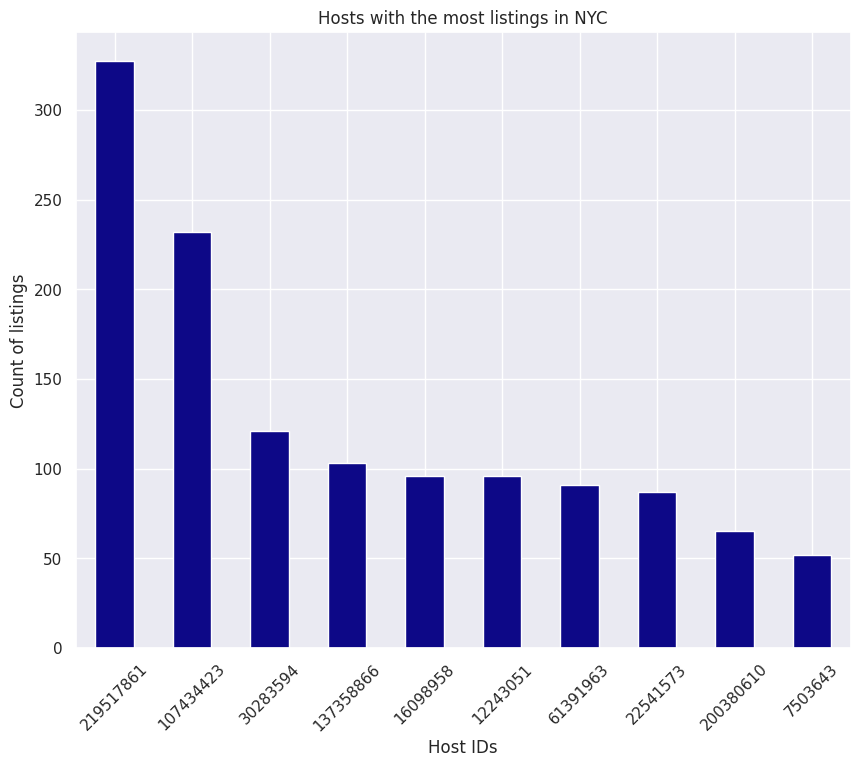

In [ ]:
#setting figure size for future visualizations
sns.set(rc={'figure.figsize':(10,8)})
viz_1=top_host.plot(kind='bar',cmap='plasma')
viz_1.set_title('Hosts with the most listings in NYC')
viz_1.set_ylabel('Count of listings')
viz_1.set_xlabel('Host IDs')
viz_1.set_xticklabels(viz_1.get_xticklabels(), rotation=45)

the host with maximum number of listings registered for airbnb in NewYork has 372 listings.

<Axes: xlabel='neighbourhood_group'>

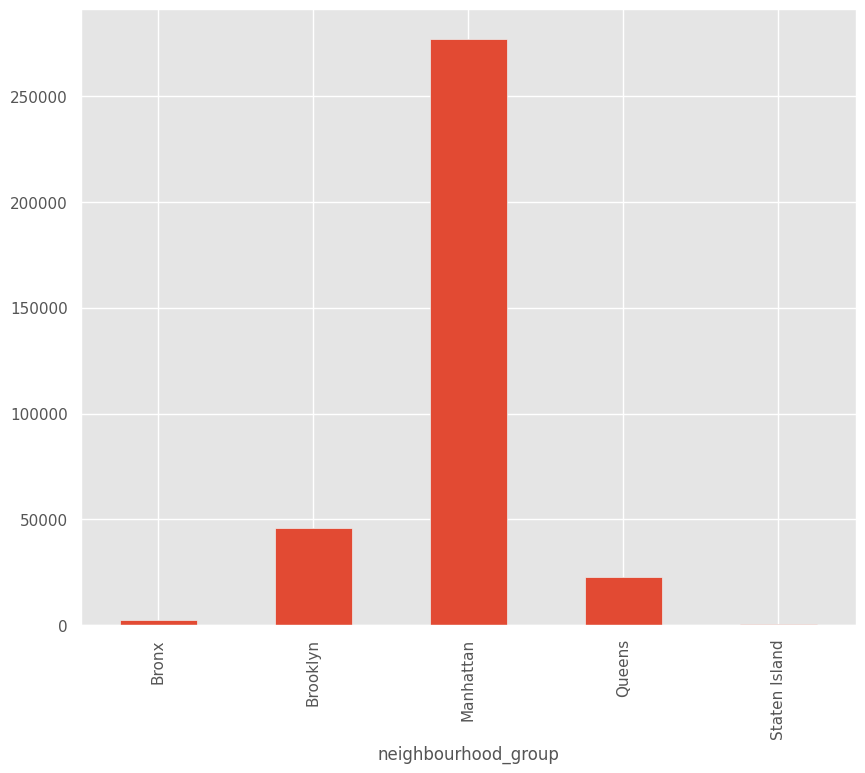

In [ ]:
#Listings per neighbourhood group
a=data_abb.groupby('neighbourhood_group').calculated_host_listings_count.sum()
plt.style.use('ggplot')
a.plot(kind='bar')

<Axes: xlabel='neighbourhood_group', ylabel='count'>

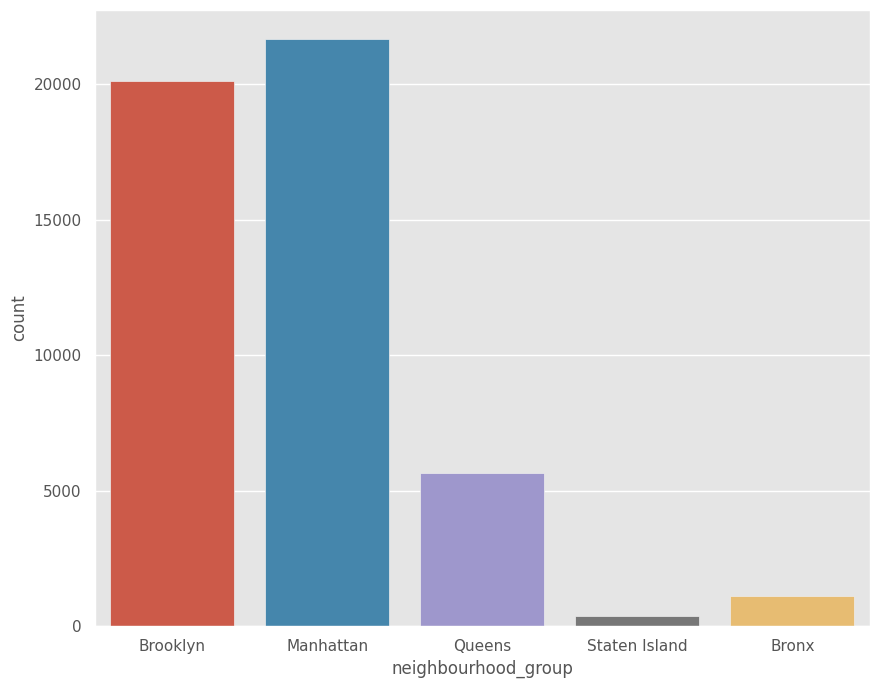

In [ ]:
sns.countplot(x='neighbourhood_group',data=data_abb)

1. Manhattan neighbourhood group has highest number of listings in whole New York area.

2. Number of hosts ownning the listings are highest in Manhattan followed by Brooklyn

neighbourhood_group
Bronx            48
Brooklyn         47
Manhattan        32
Queens           51
Staten Island    43
Name: neighbourhood, dtype: int64


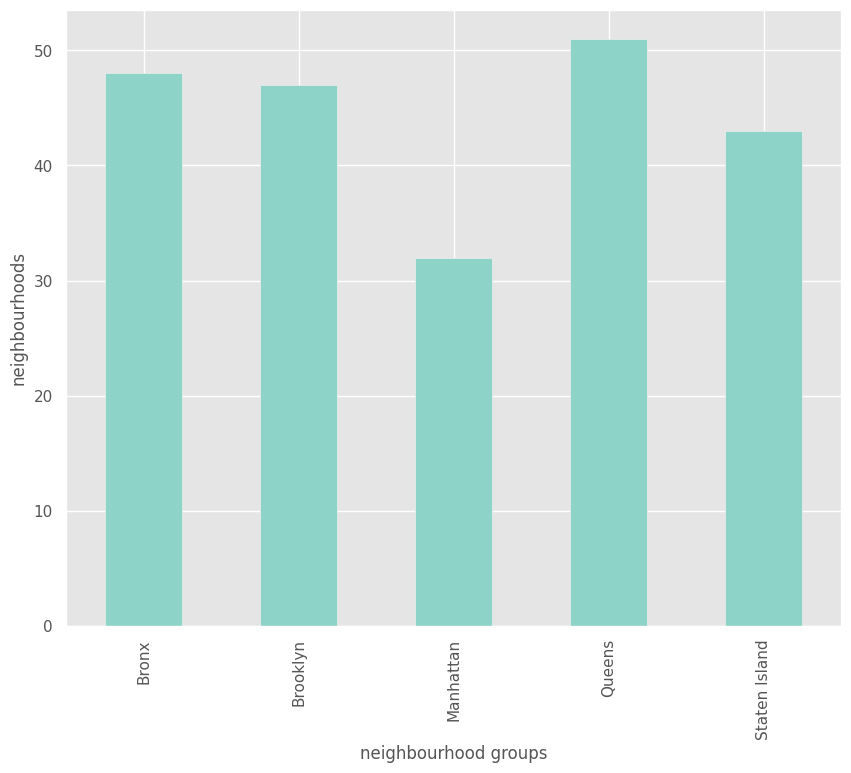

In [ ]:
data_abb.groupby('neighbourhood_group')['neighbourhood'].nunique().plot(kind='bar',colormap='Set3')
plt.xlabel('neighbourhood groups')
plt.ylabel('neighbourhoods')
print(data_abb.groupby('neighbourhood_group')['neighbourhood'].nunique())

Queens has highest number of neighbourhoods within its zone while Manhattan has lowest number of neighbourhoods. Still, number of listings registered in AirBnB is in Manhattan region.

Total neighbourhoods in NYC in which listings are located: 48895


Text(0, 0.5, 'Listings')

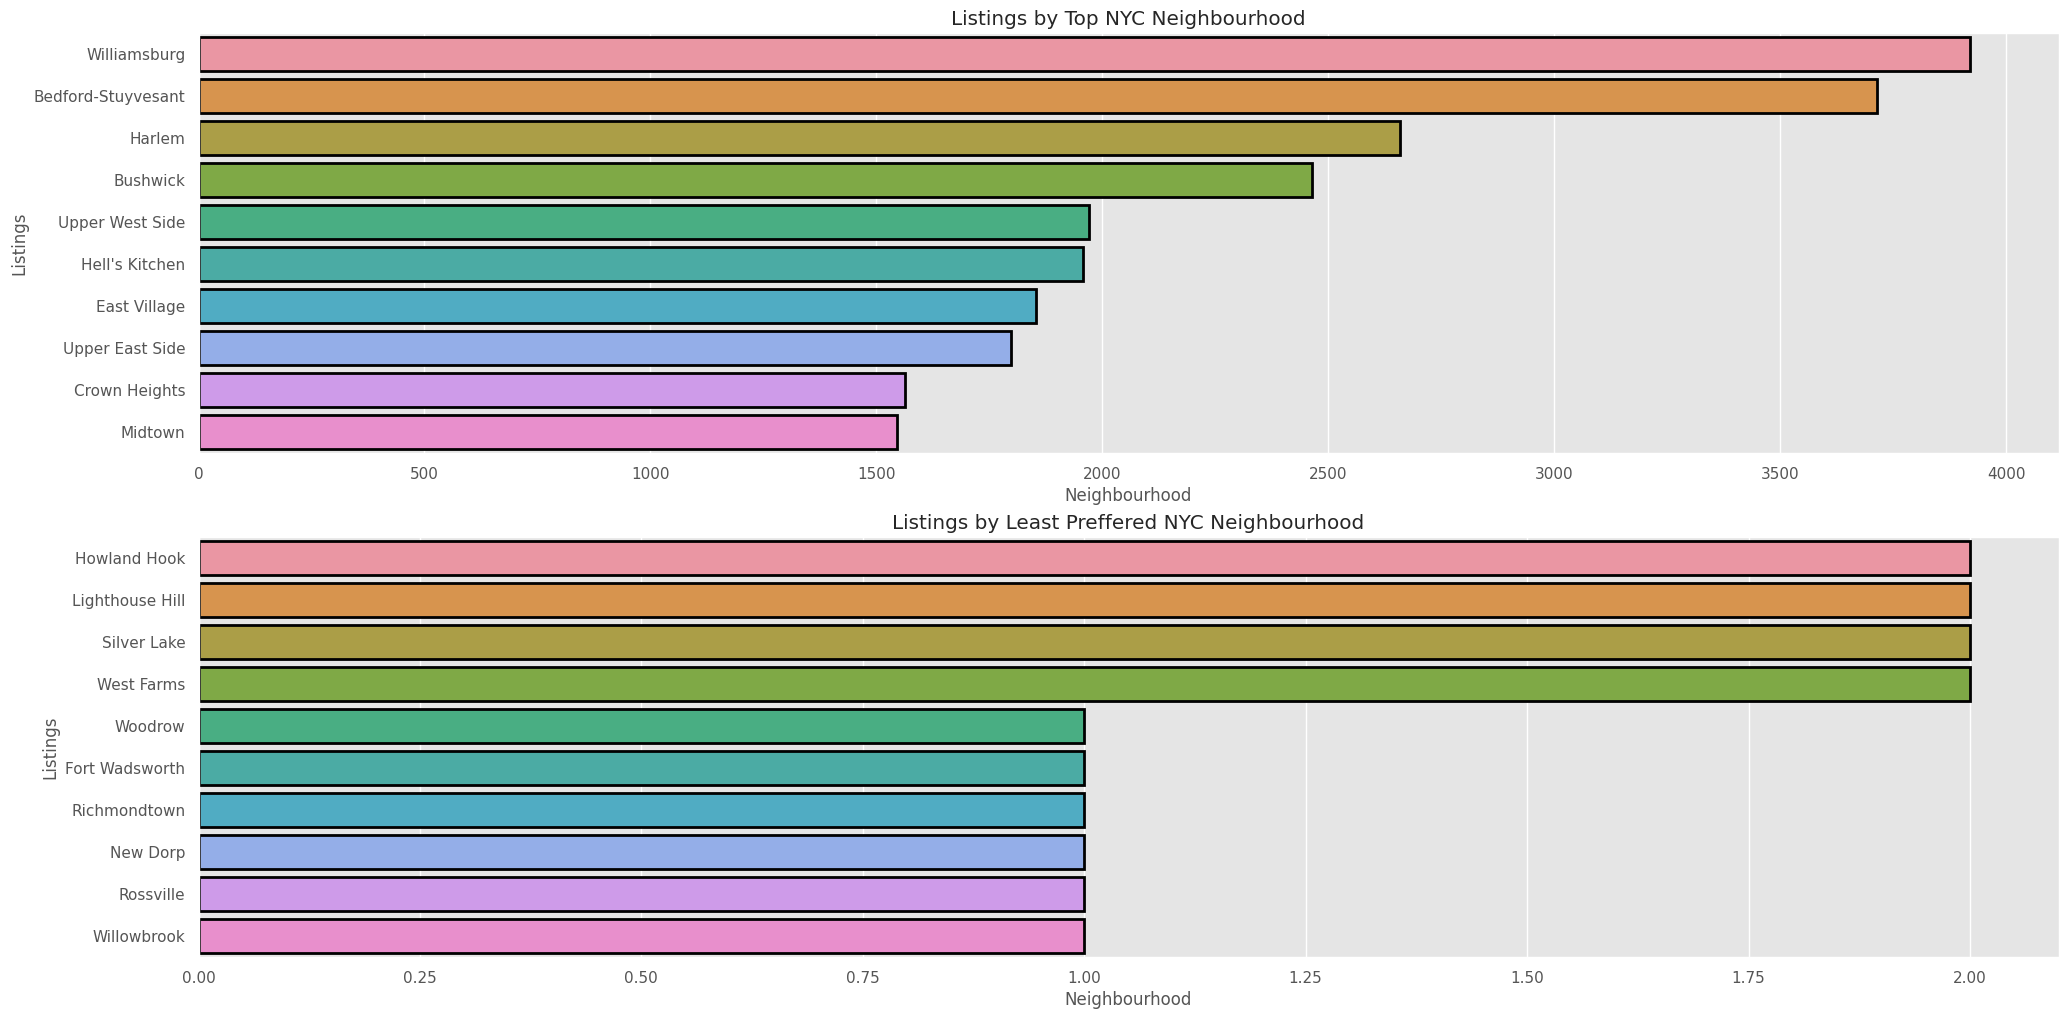

In [ ]:
print('Total neighbourhoods in NYC in which listings are located: {}'.format(data_abb.neighbourhood.value_counts().sum()))

plt.figure(figsize=(24,12))
# Top 10 neighbourhoods in NYC
plt.subplot(2,1,1)
V2=sns.countplot(y='neighbourhood',                                            #Create a Horizontal Plot
                   data=data_abb,
                   order=data_abb.neighbourhood.value_counts().iloc[:10].index,      #We want to view the top 10 Neighbourhoods
                   edgecolor=(0,0,0),                                            #This cutomization gives us black borders around our plot bars
                   linewidth=2)
V2.set_title('Listings by Top NYC Neighbourhood')                                #Set Title
V2.set_xlabel('Neighbourhood')
V2.set_ylabel('Listings')

# 10 Least preferred neighbourhood in NYC
plt.subplot(2,1,2)
V3 = sns.countplot(y='neighbourhood',                                    #Create a Horizontal Plot
                     data=data_abb,
                   order=data_abb.neighbourhood.value_counts().iloc[-10:].index,      #We want to view the top 10 Neighbourhoods
                   edgecolor=(0,0,0),                                            #This cutomization gives us black borders around our plot bars
                   linewidth=2)
V3.set_title('Listings by Least Preffered NYC Neighbourhood')                                #Set Title
V3.set_xlabel('Neighbourhood')
V3.set_ylabel('Listings')

### Room type analysis

In [ ]:
data_abb.room_type.unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

Entire home/apt    25409
Private room       22326
Shared room         1160
Name: room_type, dtype: int64

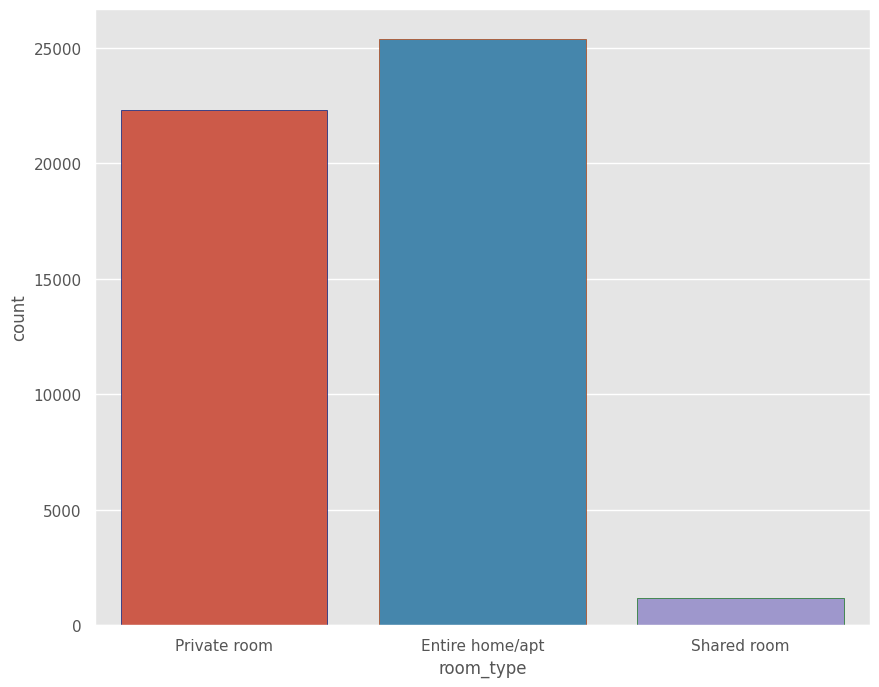

In [ ]:
sns.countplot(x='room_type',data=data_abb,edgecolor=sns.color_palette("dark", 3))
data_abb.room_type.value_counts()

In [ ]:
print('Percentage of room types available in AirBnB registered listings are:\n {}'.format((data_abb.room_type.value_counts()/len(data_abb.room_type))*100))

Percentage of room types available in AirBnB registered listings are:
 Entire home/apt    51.966459
Private room       45.661111
Shared room         2.372431
Name: room_type, dtype: float64


Text(0.5, 1.0, 'Room types availability in AirBnB')

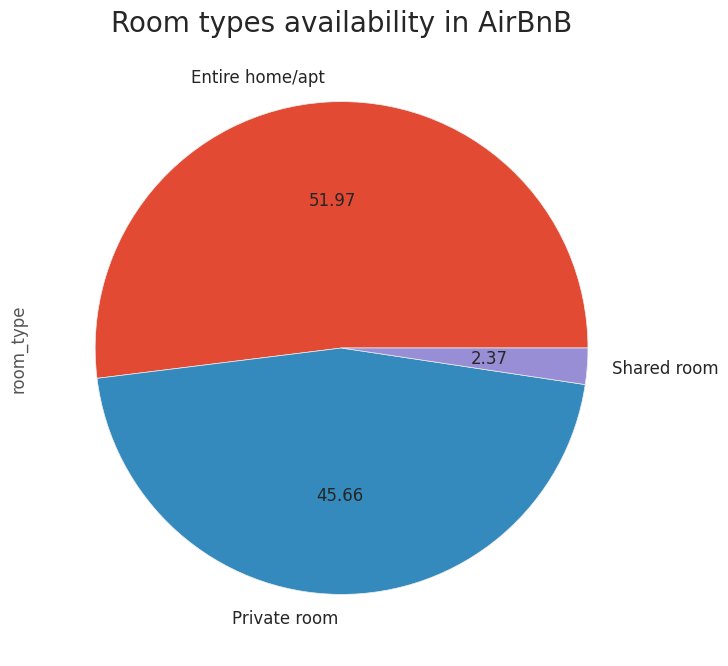

In [ ]:
b=data_abb.room_type.value_counts()/len(data_abb.room_type)
b.plot.pie(autopct='%.2f',fontsize=12,figsize=(8,8))
plt.title('Room types availability in AirBnB',fontsize=20)

Text(0.5, 1.0, 'Neighbourhood groups Vs Room types availability')

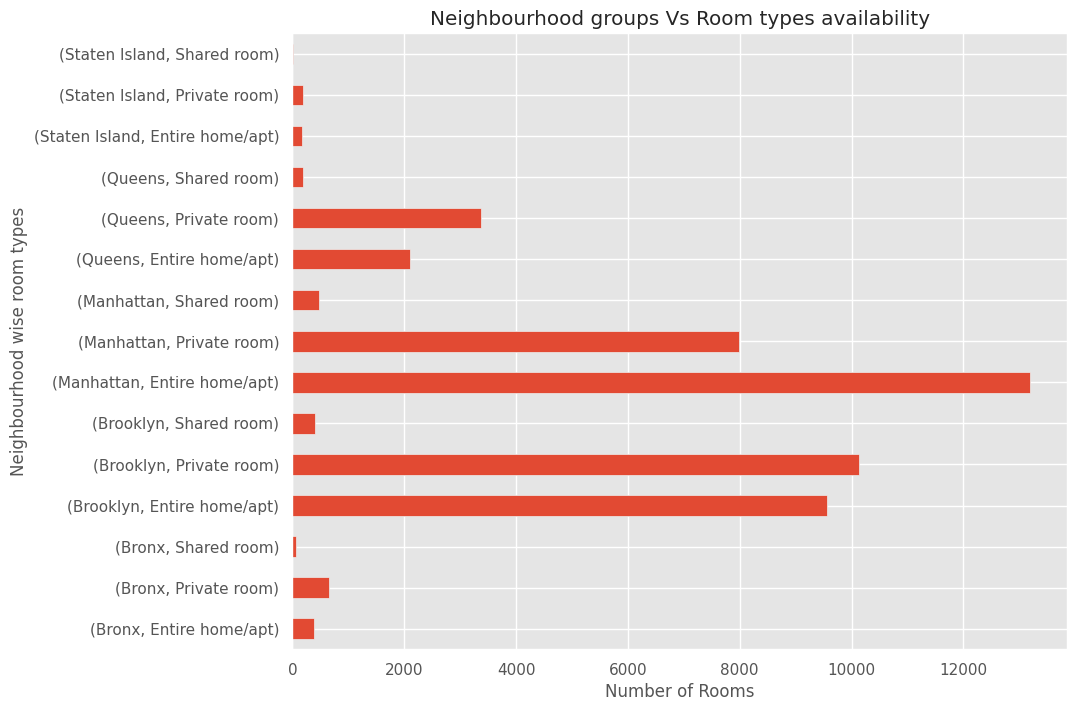

In [ ]:
data_abb.groupby(['neighbourhood_group','room_type']).room_type.count().plot.barh(stacked=True)
plt.ylabel('Neighbourhood wise room types')
plt.xlabel('Number of Rooms')
plt.title('Neighbourhood groups Vs Room types availability')

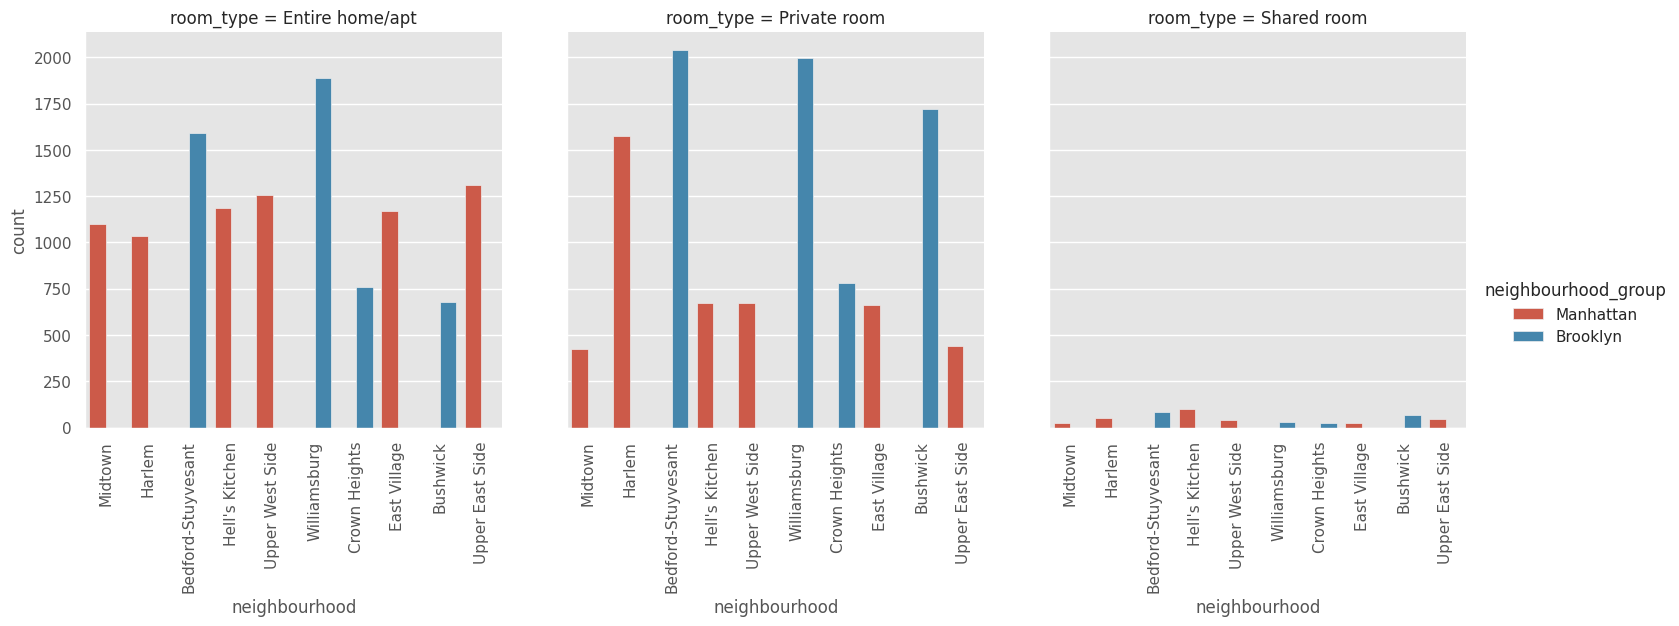

In [ ]:
#let's now combine this with our boroughs and room type for a rich visualization we can make

#grabbing top 10 neighbourhoods for sub-dataframe
sub=data_abb.loc[data_abb['neighbourhood'].isin(['Williamsburg','Bedford-Stuyvesant','Harlem','Bushwick',
                 'Upper West Side','Hell\'s Kitchen','East Village','Upper East Side','Crown Heights','Midtown'])]
#using catplot to represent multiple interesting attributes together and a count
viz=sns.catplot(x='neighbourhood', hue='neighbourhood_group', col='room_type', data=sub, kind='count')
viz.set_xticklabels(rotation=90)

In all the listings of rooms registered in AirBnB more than 50% of listings offer complete houses or apartments and remaining are private rooms. Only 2% of listings offer shared rooms.

Brooklyn is a zone which has maximum listings offering private rooms while manhattan is an hub of apartment offerings, followed by Brooklyn.

Bronx, Queen and Staten Island has least number of listings registered and does not offer much of the services.

### **Price wise analysis of rooms**

In [ ]:
data_abb.groupby('neighbourhood_group').price.describe()

,count,mean,std,min,25%,50%,75%,max
neighbourhood_group,,,,,,,,
Bronx,1091.0,87.496792,106.709349,0.0,45.0,65.0,99.0,2500.0
Brooklyn,20104.0,124.383207,186.873538,0.0,60.0,90.0,150.0,10000.0
Manhattan,21661.0,196.875814,291.383183,0.0,95.0,150.0,220.0,10000.0
Queens,5666.0,99.517649,167.102155,10.0,50.0,75.0,110.0,10000.0
Staten Island,373.0,114.812332,277.620403,13.0,50.0,75.0,110.0,5000.0


In [ ]:
data_abb

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price
0,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,1,9,2018-10-19,0.21,6,365,149
1,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,1,45,2019-05-21,0.38,2,355,225
2,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,3,0,2019-07-08,0.00,1,365,150
3,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,1,270,2019-07-05,4.64,1,194,89
4,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,10,9,2018-11-19,0.10,1,0,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,8232441,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,2,0,2019-07-08,0.00,2,9,70
48891,6570630,Brooklyn,Bushwick,40.70184,-73.93317,Private room,4,0,2019-07-08,0.00,2,36,40
48892,23492952,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,10,0,2019-07-08,0.00,1,27,115
48893,30985759,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,1,0,2019-07-08,0.00,6,2,55


In [ ]:
# setting up bins for price in order to have better understanding of rooms distribution
data_abb['price_range']=pd.qcut(data_abb['price'],10)

In [ ]:
list(data_abb.neighbourhood_group.unique())

['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx']

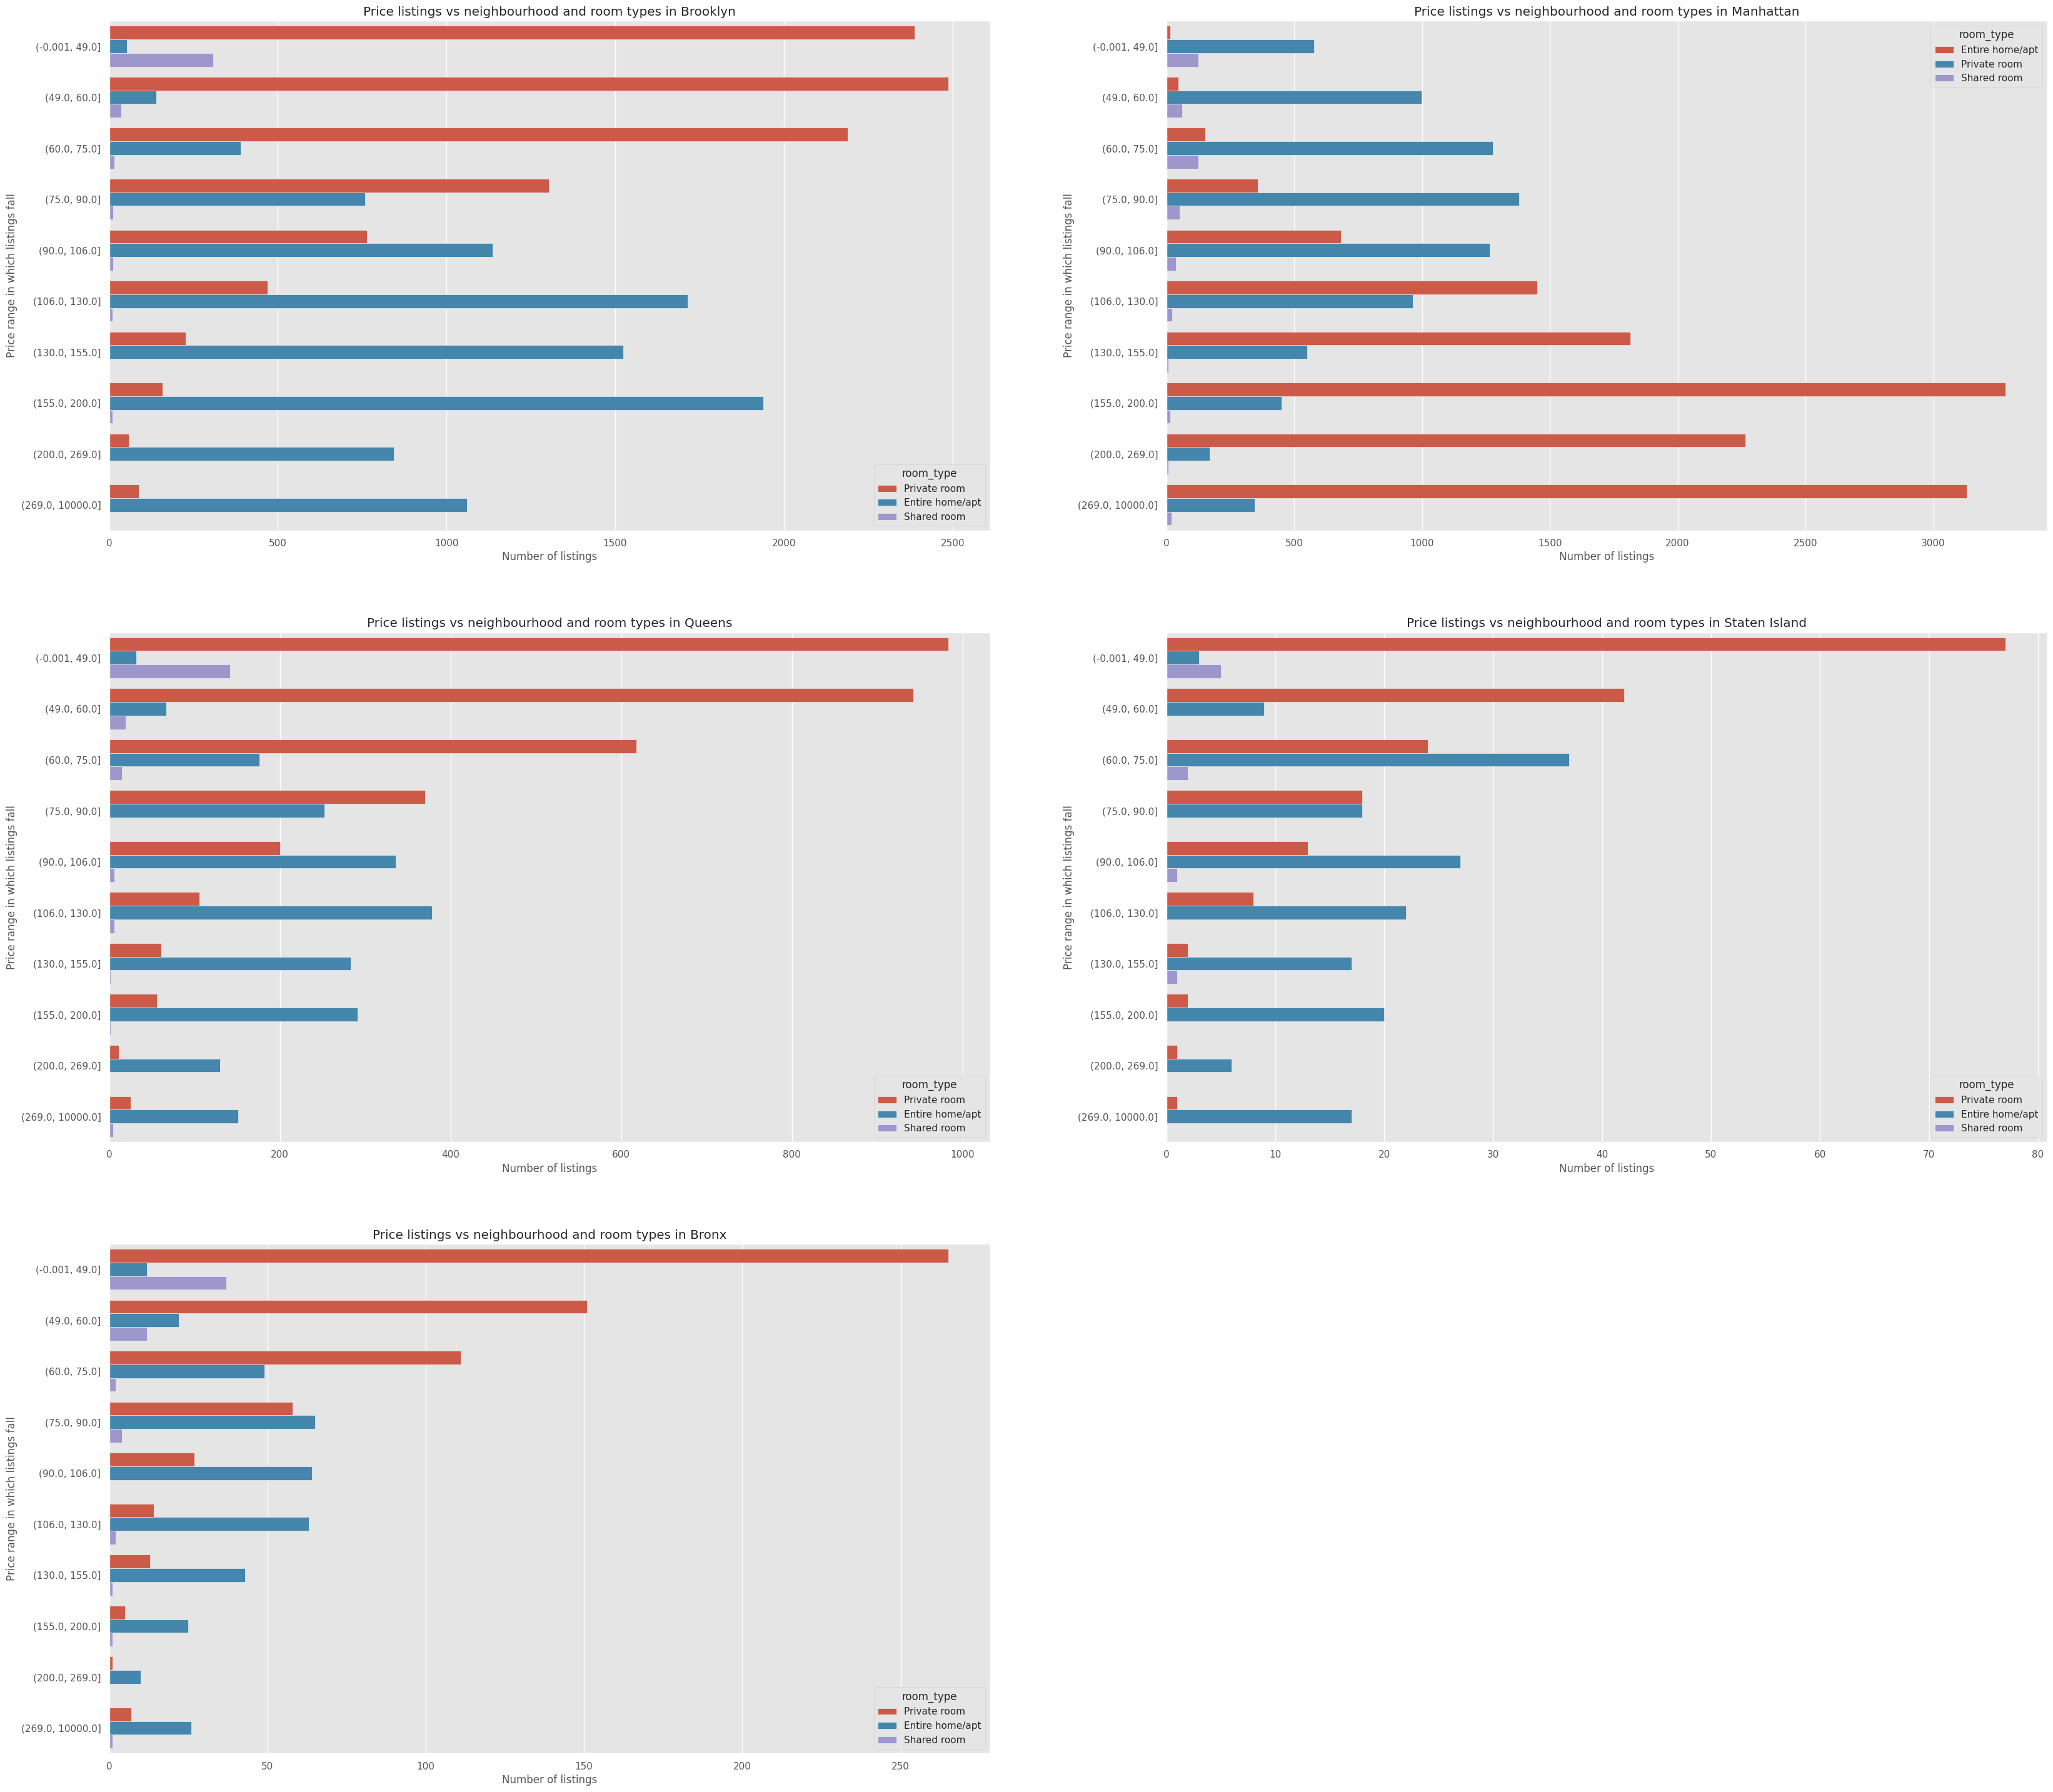

In [ ]:
neighbourhood_group=list(data_abb.neighbourhood_group.unique())
plt.figure(figsize=(40,36))
for i,neighbour in enumerate(neighbourhood_group):
    plt.subplot(3,2,i+1)
    sns.countplot(y='price_range',hue='room_type',data=data_abb[data_abb['neighbourhood_group']==neighbour])
    plt.xlabel('Number of listings')
    plt.ylabel('Price range in which listings fall')
    plt.title('Price listings vs neighbourhood and room types in {}'.format(neighbour))

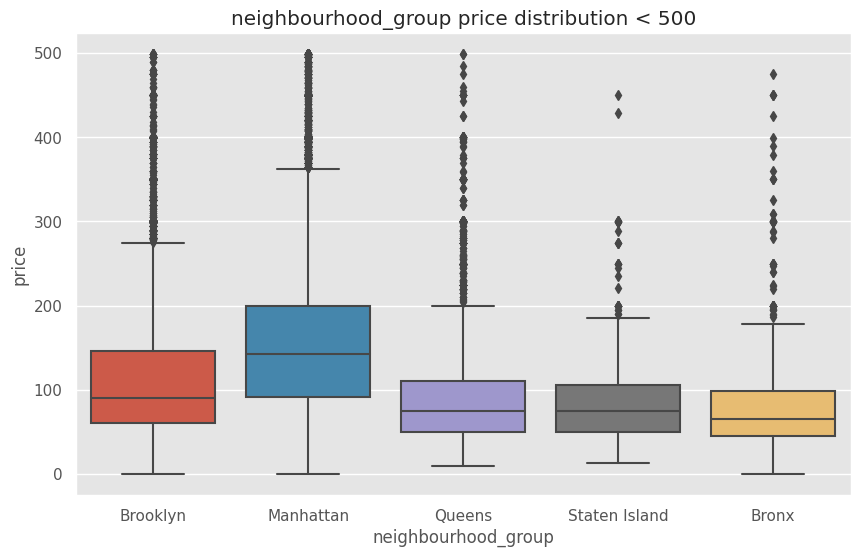

In [ ]:
g = data_abb[data_abb.price <500]
plt.figure(figsize=(10,6))
sns.boxplot(y="price",x ='neighbourhood_group' ,data = g)
plt.title("neighbourhood_group price distribution < 500")
plt.show()

<ipython-input-44-af3c3ef9a972>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_abb[data_abb.neighbourhood_group=='Manhattan'].price,color='maroon',hist=False,label='Manhattan')
<ipython-input-44-af3c3ef9a972>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_abb[data

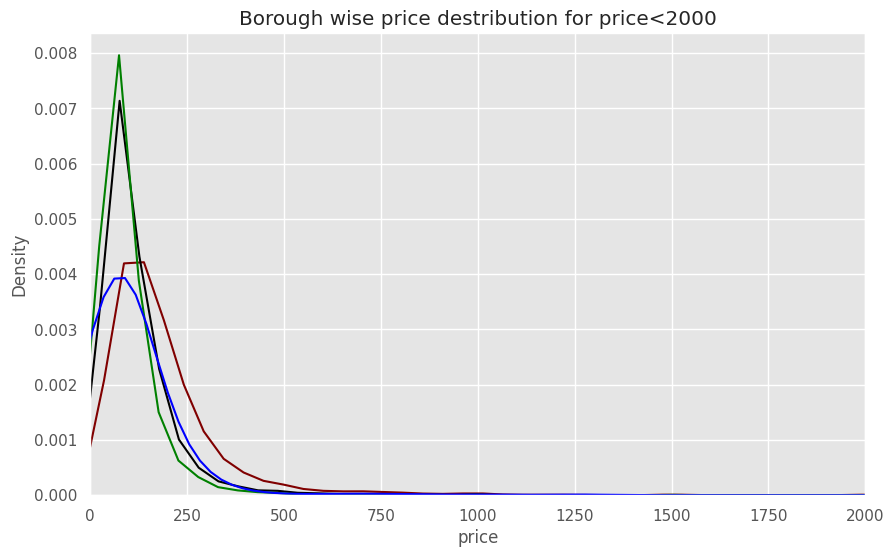

In [ ]:
plt.figure(figsize=(10,6))
sns.distplot(data_abb[data_abb.neighbourhood_group=='Manhattan'].price,color='maroon',hist=False,label='Manhattan')
sns.distplot(data_abb[data_abb.neighbourhood_group=='Brooklyn'].price,color='black',hist=False,label='Brooklyn')
sns.distplot(data_abb[data_abb.neighbourhood_group=='Queens'].price,color='green',hist=False,label='Queens')
sns.distplot(data_abb[data_abb.neighbourhood_group=='Staten Island'].price,color='blue',hist=False,label='Staten Island')
sns.distplot(data_abb[data_abb.neighbourhood_group=='Long Island'].price,color='lavender',hist=False,label='Long Island')
plt.title('Borough wise price destribution for price<2000')
plt.xlim(0,2000)
plt.show()

1. In all listings registered in AirBnB New York, private rooms are most expensive in Manhattan region with an average price of registered listing being 197 dollars, and average price of private room is 116.78 dollars and individual apartment being 249.23 dollars.

2. The neighbourhood region with maximum number of affordable rooms is Brooklyn with more than 10000 private rooms with average price of 76 dollars and average price of entire apartment around 178 dollars.

3. The cheapest neighbourhood is Staten with an average price of 66 dollars and 127 dollars for private rooms and apartments respectively. Maximum price of apartment and private rooms in this neighbourgood is 1000 dollars and 2500 dollars respectively.

4. Manhattan is the most expensive region followed by Brooklyn.

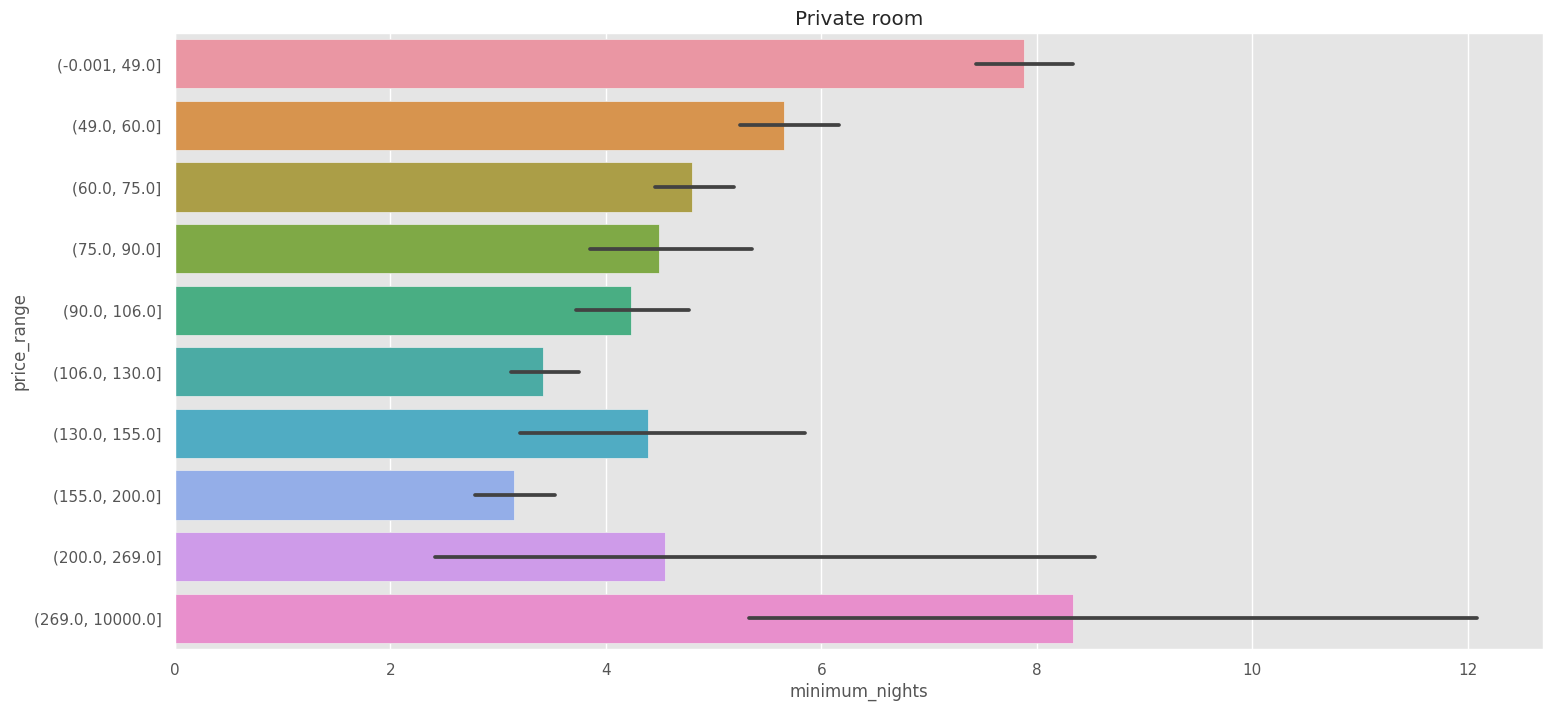

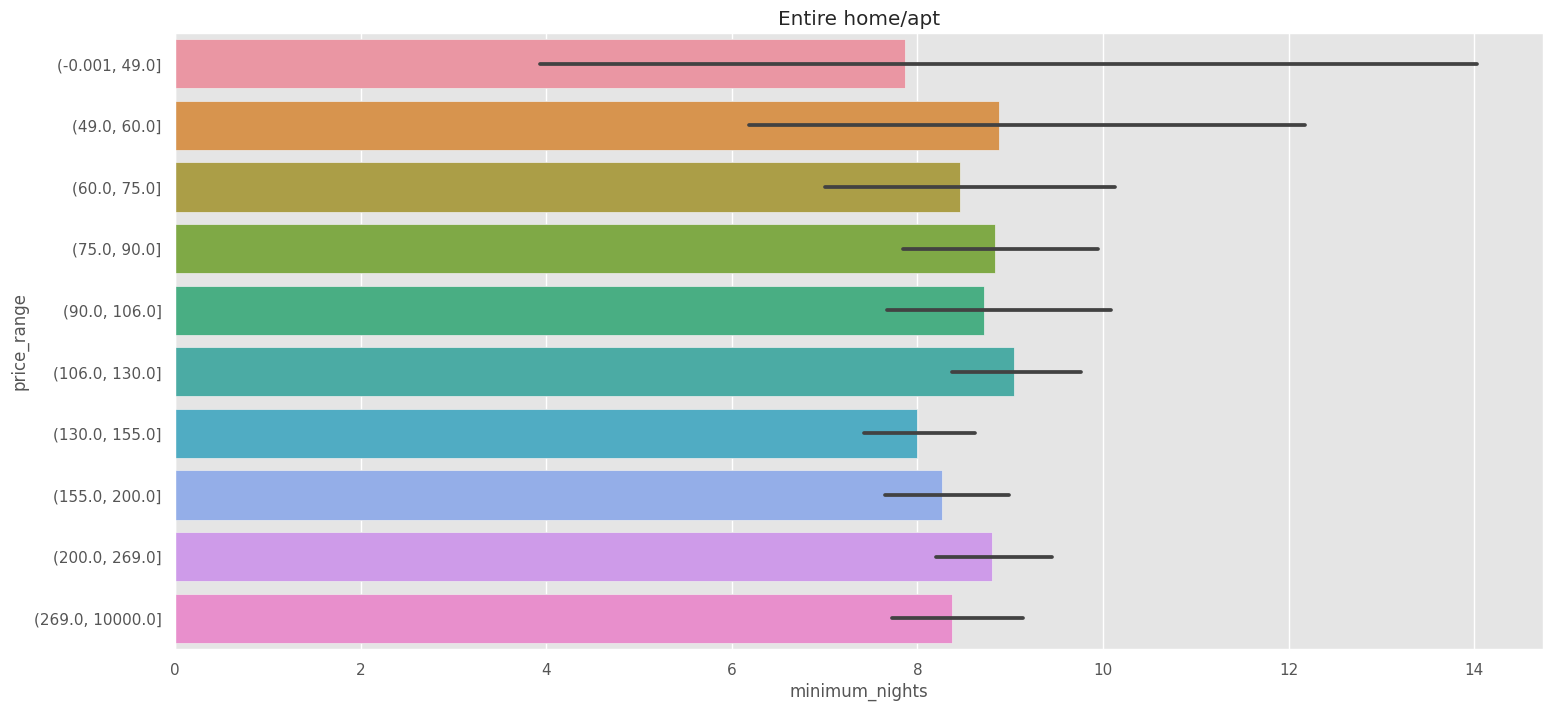

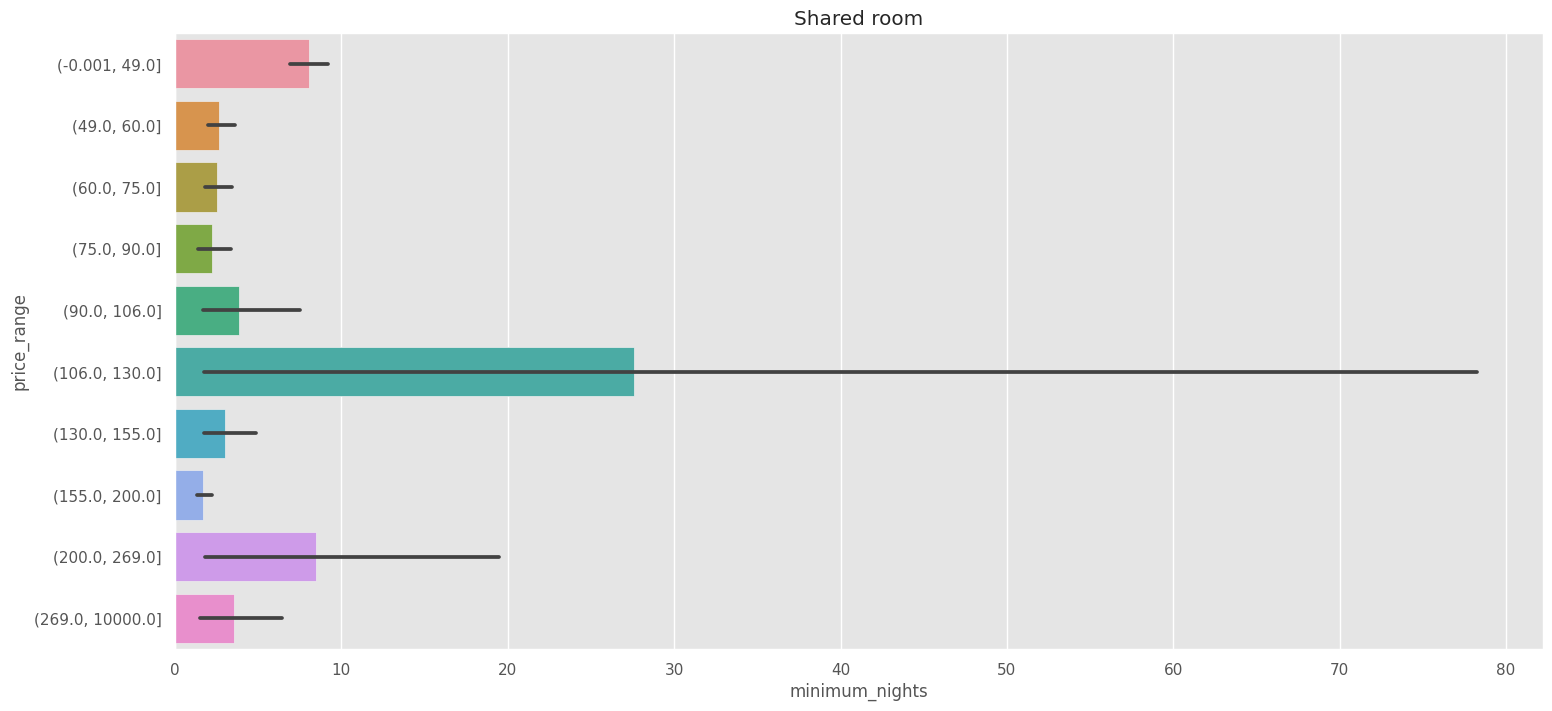

In [ ]:
rooms=list(data_abb.room_type.unique())
for i,room in enumerate(rooms):
    plt.figure(figsize=(60,8))
    plt.subplot(1,3,i+1)
    sns.barplot(y='price_range',x='minimum_nights',data=data_abb[(data_abb.room_type==room)])

    plt.title(room)

<Axes: xlabel='minimum_nights', ylabel='price'>

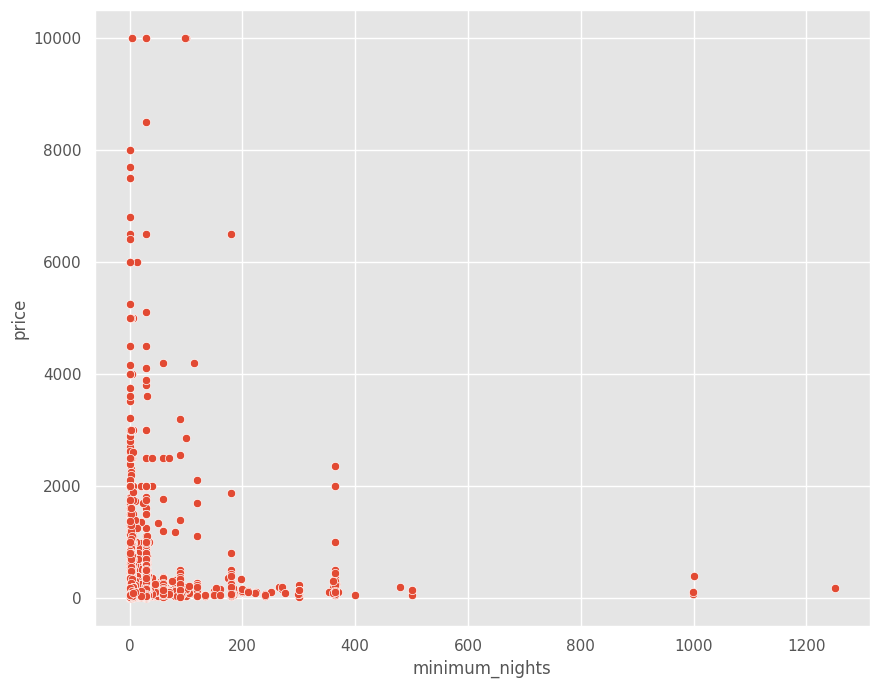

In [ ]:
sns.scatterplot(x='minimum_nights',y='price',data=data_abb)

### **Minimum Nights and price range**

In [ ]:
data_abb.groupby(['room_type','price_range'])['minimum_nights'].describe()

count       mean         std  min  25%  \
room_type       price_range                                                 
Entire home/apt (-0.001, 49.0]     117.0   7.863248   29.105014  1.0  1.0   
                (49.0, 60.0]       285.0   8.880702   26.800774  1.0  1.0   
                (60.0, 75.0]       804.0   8.456468   23.977300  1.0  2.0   
                (75.0, 90.0]      1452.0   8.841598   20.166426  1.0  2.0   
                (90.0, 106.0]     2247.0   8.713841   30.093155  1.0  2.0   
                (106.0, 130.0]    3628.0   9.039691   21.723164  1.0  2.0   
                (130.0, 155.0]    3683.0   7.996742   18.926184  1.0  2.0   
                (155.0, 200.0]    5556.0   8.260259   24.731107  1.0  2.0   
                (200.0, 269.0]    3253.0   8.807255   18.788983  1.0  2.0   
                (269.0, 10000.0]  4384.0   8.369526   23.459741  1.0  2.0   
Private room    (-0.001, 49.0]    4291.0   7.883011   15.582768  1.0  1.0   
                (49.0, 60.0]      4621.0   5.655053   15.478208  1.0  1.0   
                (60.0, 75.0]      4219.0   4.799953   11.957915  1.0  1.0   
                (75.0, 90.0]      3129.0   4.495366   21.635023  1.0  1.0   
                (90.0, 106.0]     2270.0   4.235242   13.785078  1.0  1.0   
                (106.0, 130.0]    1562.0   3.412932    6.536482  1.0  1.0   
                (130.0, 155.0]     854.0   4.394614   21.102164  1.0  1.0   
                (155.0, 200.0]     673.0   3.147103    5.138040  1.0  1.0   
                (200.0, 269.0]     242.0   4.549587   24.433660  1.0  1.0   
                (269.0, 10000.0]   465.0   8.333333   36.615939  1.0  1.0   
Shared room     (-0.001, 49.0]     619.0   8.051696   14.419756  1.0  1.0   
                (49.0, 60.0]       130.0   2.669231    5.032281  1.0  1.0   
                (60.0, 75.0]       161.0   2.534161    5.108854  1.0  1.0   
                (75.0, 90.0]        70.0   2.257143    4.570497  1.0  1.0   
                (90.0, 106.0]       57.0   3.877193   13.220750  1.0  1.0   
                (106.0, 130.0]      40.0  27.600000  157.600078  1.0  1.0   
                (130.0, 155.0]      15.0   3.000000    3.464102  1.0  1.0   
                (155.0, 200.0]      28.0   1.714286    1.329359  1.0  1.0   
                (200.0, 269.0]      11.0   8.454545   17.494934  1.0  1.0   
                (269.0, 10000.0]    29.0   3.551724    7.023360  1.0  1.0   

                                  50%  75%     max  
room_type       price_range                         
Entire home/apt (-0.001, 49.0]    2.0  4.0   300.0  
                (49.0, 60.0]      3.0  5.0   365.0  
                (60.0, 75.0]      3.0  6.0   500.0  
                (75.0, 90.0]      3.0  7.0   365.0  
                (90.0, 106.0]     3.0  5.0   999.0  
                (106.0, 130.0]    3.0  6.0   370.0  
                (130.0, 155.0]    3.0  6.0   500.0  
                (155.0, 200.0]    3.0  5.0  1250.0  
                (200.0, 269.0]    3.0  6.0   366.0  
                (269.0, 10000.0]  3.0  5.0  1000.0  
Private room    (-0.001, 49.0]    3.0  7.0   500.0  
                (49.0, 60.0]      2.0  4.0   500.0  
                (60.0, 75.0]      2.0  4.0   365.0  
                (75.0, 90.0]      2.0  3.0   999.0  
                (90.0, 106.0]     2.0  3.0   365.0  
                (106.0, 130.0]    2.0  3.0   120.0  
                (130.0, 155.0]    2.0  3.0   365.0  
                (155.0, 200.0]    2.0  3.0    45.0  
                (200.0, 269.0]    2.0  3.0   365.0  
                (269.0, 10000.0]  2.0  3.0   365.0  
Shared room     (-0.001, 49.0]    2.0  7.0   120.0  
                (49.0, 60.0]      1.0  2.0    35.0  
                (60.0, 75.0]      1.0  2.0    30.0  
                (75.0, 90.0]      1.0  2.0    30.0  
                (90.0, 106.0]     1.0  2.0   100.0  
                (106.0, 130.0]    1.0  3.0   999.0  
                (130.0, 155.0]    2.0  3.0    15.0  
                (155.0, 200.0]   

1. Minimum number of night stays has no significant impact on prices.

2. In case of private rooms, price range for longer duration with minimum stay of 8 nights and above is quite on a higher side. People pays huge amount to stay for longer days.

### **Area wise visualization of availability of listings**

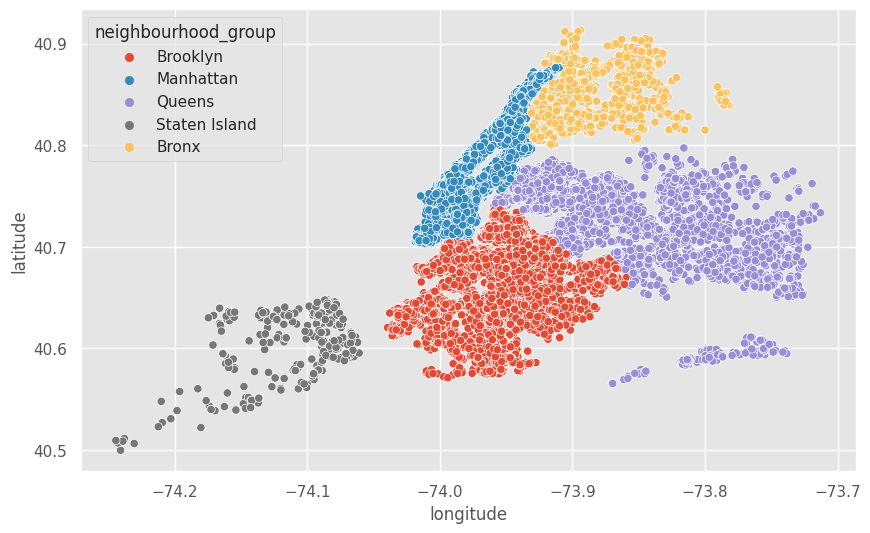

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_abb, x='longitude', y='latitude', hue='neighbourhood_group')
plt.show()

In [ ]:
import folium
from folium.plugins import HeatMap
m=folium.Map([40.7128,-74.0060],zoom_start=11)
HeatMap(data_abb[['latitude','longitude']].dropna(),radius=8,gradient={0.2:'blue',0.4:'purple',0.6:'orange',1.0:'red'}).add_to(m)
display(m)

More darker the heatmap means more the concentration of listing in the area.

### *Top listings and their prices*

Assumption: I am assuming that since reviews sentiment is not provided it is possible that all reviews given are positive and more the positive reviews, more are preferences for those listings.

In [ ]:
#let's grab 100 most reviewed listings in NYC
top_reviewed_listings=data_abb.nlargest(100,'number_of_reviews')
top_reviewed_listings

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price,price_range
11759,47621202,Queens,Jamaica,40.66730,-73.76831,Private room,1,629,2019-07-05,14.58,2,333,47,"(-0.001, 49.0]"
2031,4734398,Manhattan,Harlem,40.82085,-73.94025,Private room,1,607,2019-06-21,7.75,3,293,49,"(-0.001, 49.0]"
2030,4734398,Manhattan,Harlem,40.82124,-73.93838,Private room,1,597,2019-06-23,7.72,3,342,49,"(-0.001, 49.0]"
2015,4734398,Manhattan,Harlem,40.82264,-73.94041,Private room,1,594,2019-06-15,7.57,3,339,49,"(-0.001, 49.0]"
13495,47621202,Queens,Jamaica,40.66939,-73.76975,Private room,1,576,2019-06-27,13.40,2,173,47,"(-0.001, 49.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7317,27944388,Manhattan,East Harlem,40.80226,-73.94506,Private room,1,325,2019-06-19,6.19,1,108,70,"(60.0, 75.0]"
22100,121391142,Queens,Springfield Gardens,40.66600,-73.76333,Private room,1,325,2019-06-12,11.72,2,0,65,"(60.0, 75.0]"
116,115307,Brooklyn,Williamsburg,40.71942,-73.95748,Entire home/apt,3,324,2019-06-23,3.01,1,107,325,"(269.0, 10000.0]"
2111,5239845,Brooklyn,Bushwick,40.69288,-73.90374,Private room,2,324,2019-06-28,4.30,1,267,62,"(60.0, 75.0]"


In [ ]:
price_avrg=top_reviewed_listings.price.mean()
print('Average price per night: {}'.format(price_avrg))

Average price per night: 95.53


In [ ]:
top_reviewed_listings.groupby('room_type')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,25.0,170.480000,103.111639,49.0,115.00,145.0,189.0,575.0
Private room,74.0,70.972973,27.156559,29.0,49.25,65.0,89.5,163.0
Shared room,1.0,39.000000,NaN,39.0,39.00,39.0,39.0,39.0


1. Most of listings who got more reviews have private rooms.
2. Probably people prefer to book apartment or private rooms as compared to shared room and give reviews.
3. Average price for preferred apartment is 170 dollars and 74 dollars for private rooms.

<Axes: xlabel='room_type', ylabel='price'>

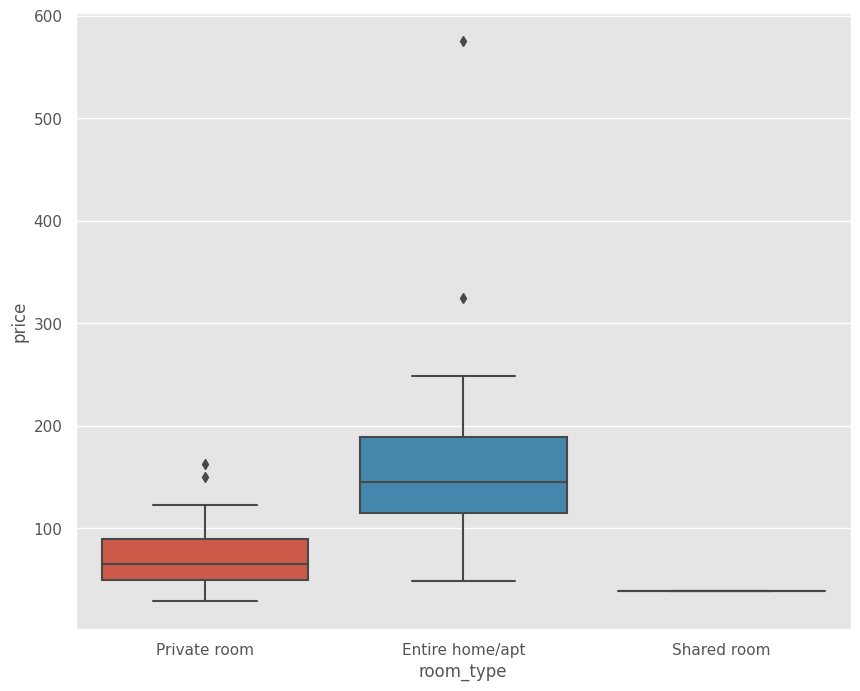

In [ ]:
sns.boxplot(y='price',x='room_type',data=top_reviewed_listings)

<ipython-input-56-bd80a7ba92e1>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_abb[(data_abb['minimum_nights'] <= 30) & (data_abb['minimum_nights'] > 0)]['minimum_nights'], bins=31)


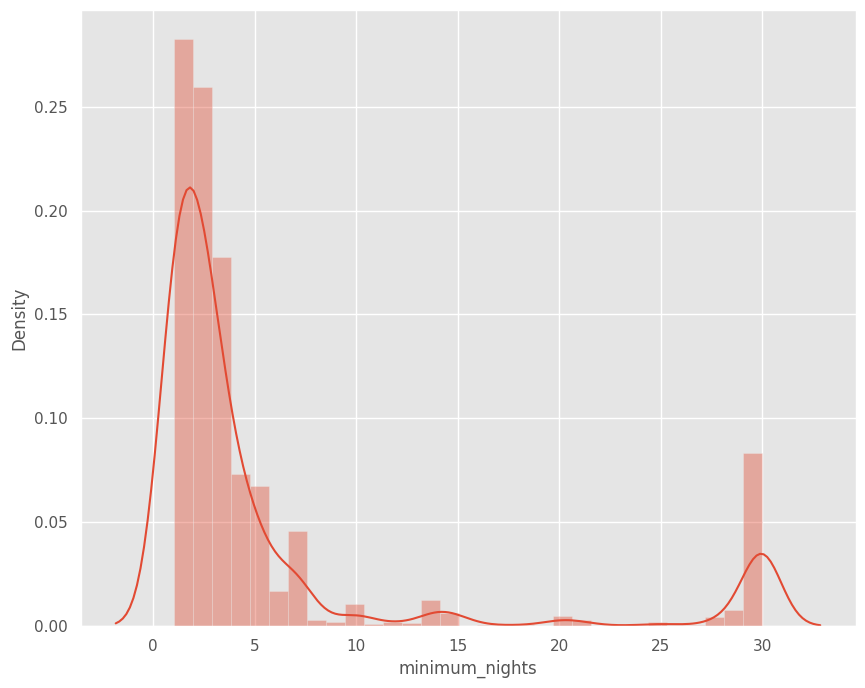

In [ ]:
#Room availability
sns.distplot(data_abb[(data_abb['minimum_nights'] <= 30) & (data_abb['minimum_nights'] > 0)]['minimum_nights'], bins=31)
plt.ioff()

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(data_abb.longitude, data_abb.latitude, c=data_abb.availability_365, cmap='spring', edgecolor='black', linewidth=1, alpha=0.75)

cbar = plt.colorbar()
cbar.set_label('availability_365')

Most of the listings have room availability for booking for minimum of 1 day

### **Correlation among variables**

In [ ]:
data_abb.corr()

<ipython-input-58-a507f01ffd49>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  data_abb.corr()


,host_id,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price
host_id,1.000000,0.020224,0.127055,-0.017364,-0.140106,0.209783,0.154950,0.203492,0.015309
latitude,0.020224,1.000000,0.084788,0.024869,-0.015389,-0.018758,0.019517,-0.010983,0.033939
longitude,0.127055,0.084788,1.000000,-0.062747,0.059094,0.138516,-0.114713,0.082731,-0.150019
minimum_nights,-0.017364,0.024869,-0.062747,1.000000,-0.080116,-0.124905,0.127960,0.144303,0.042799
number_of_reviews,-0.140106,-0.015389,0.059094,-0.080116,1.000000,0.589407,-0.072376,0.172028,-0.047954
reviews_per_month,0.209783,-0.018758,0.138516,-0.124905,0.589407,1.000000,-0.047312,0.163732,-0.050564
calculated_host_listings_count,0.154950,0.019517,-0.114713,0.127960,-0.072376,-0.047312,1.000000,0.225701,0.057472
availability_365,0.203492,-0.010983,0.082731,0.144303,0.172028,0.163732,0.225701,1.000000,0.081829
price,0.015309,0.033939,-0.150019,0.042799,-0.047954,-0.050564,0.057472,0.081829,1.000000


## ***price prediction ML model***

1. Linear Regression
2. Decision Tree

In [ ]:
# We will make model to only use listings which has price set up. Their are multiple listings with no prices.
# We will also use listings which has availability_365>0
data_abb=data_abb[data_abb.price>0]
data_abb=data_abb[data_abb.availability_365>0]

In [ ]:
# Setting the target variable and independent variable
X=['latitude','longitude','minimum_nights','number_of_reviews','availability_365','room_type','neighbourhood_group','neighbourhood']
y='price'

In [ ]:
data_X=data_abb[X]

In [ ]:
data_X.head()

,latitude,longitude,minimum_nights,number_of_reviews,availability_365,room_type,neighbourhood_group,neighbourhood
0,40.64749,-73.97237,1,9,365,Private room,Brooklyn,Kensington
1,40.75362,-73.98377,1,45,355,Entire home/apt,Manhattan,Midtown
2,40.80902,-73.94190,3,0,365,Private room,Manhattan,Harlem
3,40.68514,-73.95976,1,270,194,Entire home/apt,Brooklyn,Clinton Hill
5,40.74767,-73.97500,3,74,129,Entire home/apt,Manhattan,Murray Hill


In [ ]:
data_y=data_abb[y]

In [ ]:
data_X.head()

,latitude,longitude,minimum_nights,number_of_reviews,availability_365,room_type,neighbourhood_group,neighbourhood
0,40.64749,-73.97237,1,9,365,Private room,Brooklyn,Kensington
1,40.75362,-73.98377,1,45,355,Entire home/apt,Manhattan,Midtown
2,40.80902,-73.94190,3,0,365,Private room,Manhattan,Harlem
3,40.68514,-73.95976,1,270,194,Entire home/apt,Brooklyn,Clinton Hill
5,40.74767,-73.97500,3,74,129,Entire home/apt,Manhattan,Murray Hill


In [ ]:
# encoding the categorical data for making data suitable for machine to learn
# One-hot encoding is a technique used to convert categorical variables into binary vectors
X=pd.get_dummies(data_X,prefix_sep='_',drop_first=True)

In [ ]:
X.shape

(31354, 228)

Prices are not normally distributed as well as there is alot of noise. Logarithmic conversion of data with huge variance can be normalised by logarithmic algorithm.

In [ ]:
y=np.log10(data_y)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=1)

In [ ]:
# importing important LinearRegression ML models
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

y_pred=lr.predict(X_test)

In [ ]:
# Evaluation of model

from sklearn.metrics import mean_squared_error
from sklearn import metrics
from sklearn.metrics import r2_score

print('RMSE:', np.round(np.sqrt(metrics.mean_squared_error(y_test, lr.predict(X_test))), 2))   #root mean square
print('R2 score train:', np.round(r2_score(y_train, lr.predict(X_train), multioutput='variance_weighted'), 2))   #r2 for training set
print('R2 score test:', np.round(r2_score(y_test, lr.predict(X_test), multioutput='variance_weighted'), 2))      #r2 for testing set

RMSE: 312114.2
R2 score train: 0.56
R2 score test: -1024135923497.23


this code snippet provides a concise evaluation of the machine learning model by presenting the RMSE and R2 scores on both the training and test sets. These metrics help you understand how well the model is performing and whether it is overfitting or underfitting the data.

In [ ]:
from sklearn.linear_model import BayesianRidge
br=BayesianRidge()
br.fit(X_train,y_train)
y_predict=br.predict(X_test)

In [ ]:
print('RMSE:', np.round(np.sqrt(metrics.mean_squared_error(y_test, lr.predict(X_test))), 2))
print('R2 score train:', np.round(r2_score(y_train, lr.predict(X_train), multioutput='variance_weighted'), 2)*100)     # R2 score on the training set as a percentage
print('R2 score test:', np.round(r2_score(y_test, lr.predict(X_test), multioutput='variance_weighted'), 2))

RMSE: 312114.2
R2 score train: 56.00000000000001
R2 score test: -1024135923497.23


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()                                            # Fit label encoder
le.fit(data_abb['neighbourhood_group'])
data_abb['neighbourhood_group']=le.transform(data_abb['neighbourhood_group'])    # Transform labels to normalized encoding.

le = LabelEncoder()
le.fit(data_abb['neighbourhood'])
data_abb['neighbourhood']=le.transform(data_abb['neighbourhood'])

le =LabelEncoder()
le.fit(data_abb['room_type'])
data_abb['room_type']=le.transform(data_abb['room_type'])

data_abb.sort_values(by='price',ascending=True,inplace=True)

data_abb.head()

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price,price_range
22835,97001292,3,104,40.69085,-73.79916,0,1,43,2019-06-12,1.68,1,252,10,"(-0.001, 49.0]"
31407,91034542,2,111,40.74408,-73.97803,1,5,42,2019-06-30,2.87,1,2,10,"(-0.001, 49.0]"
32810,167570251,1,188,40.66242,-73.99464,0,1,14,2018-10-28,1.06,1,4,10,"(-0.001, 49.0]"
33225,197169969,3,104,40.68939,-73.79886,0,2,22,2019-07-06,1.76,1,332,10,"(-0.001, 49.0]"
35386,47516406,3,215,40.69139,-73.86086,1,7,4,2018-10-08,0.41,2,180,10,"(-0.001, 49.0]"


In [ ]:
lm = LinearRegression()

X = data_abb[['neighbourhood_group','neighbourhood','room_type','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']]
y = np.log10(data_abb['price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

lm.fit(X_train,y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_absolute_error
y_predicts = lm.predict(X_test)

print("""
        Mean Squared Error: {}
        R2 Score: {}
        Mean Absolute Error: {}
     """.format(
        np.sqrt(metrics.mean_squared_error(y_test, y_predicts)),
        r2_score(y_test,y_predicts) * 100,
        mean_absolute_error(y_test,y_predicts)
        ))


        Mean Squared Error: 0.23559594585035462
        R2 Score: 41.13846713448028
        Mean Absolute Error: 0.17524932618899774
     


## DECISION TREE

In [ ]:
pip install --upgrade scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 41.8 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2


In [ ]:
from sklearn.tree import DecisionTreeRegressor

Reg_tree = DecisionTreeRegressor(criterion='squared_error', max_depth=3, random_state=0)
Reg_tree = Reg_tree.fit(X_train, y_train)

y_predicts = Reg_tree.predict(X_test)
print("median absolute deviation (MAD): ",np.mean(abs(np.multiply(np.array(y_test.T-y_predicts),np.array(1/y_test)))))
print("""
        Mean Squared Error: {}
        R2 Score: {}
        Mean Absolute Error: {}
     """.format(
        np.sqrt(metrics.mean_squared_error(y_test, y_predicts)),
        r2_score(y_test,y_predicts) * 100,
        mean_absolute_error(y_test,y_predicts)
        ))

median absolute deviation (MAD):  0.07891993758856267

        Mean Squared Error: 0.22321601940282695
        R2 Score: 47.1619647368602
        Mean Absolute Error: 0.16371095833232624
     


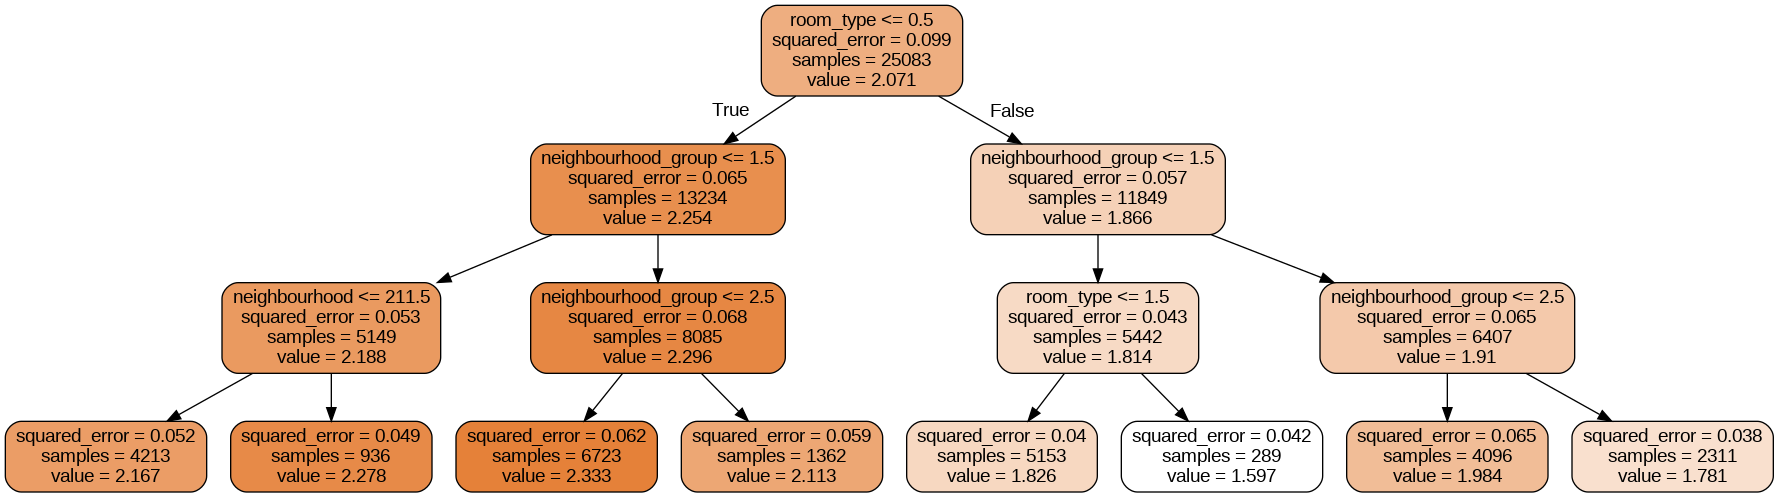

In [ ]:
from subprocess import check_call
from PIL import Image, ImageDraw, ImageFont
from IPython.display import Image as PImage
from sklearn.tree import export_graphviz
with open("tree1.dot", 'w') as f:
     f = export_graphviz(Reg_tree,
                              out_file=f,
                              max_depth = 3,
                              impurity = True,
                              feature_names = ['neighbourhood_group','neighbourhood','room_type','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365'],
                              rounded = True,
                              filled= True )
check_call(['dot','-Tpng','tree1.dot','-o','tree1.png'])
img = Image.open("tree1.png")
draw = ImageDraw.Draw(img)
img.save('sample-out.png')
PImage("sample-out.png")


In [ ]:
y=np.log10(data_abb.price)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)
Reg_tree.fit(X_train,y_train)
y_predicts=Reg_tree.predict(X_test)
from sklearn.metrics import r2_score
print('r2 score:',r2_score(y_test,y_predicts)*100,'%')

r2 score: 47.1619647368602 %
